---
## Setup & Install Library

In [ ]:
import os, json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import joblib
import random

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.utils import plot_model

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Set random seed

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

---
## Mount Google Drive + Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print('Google Drive berhasil di-mount!')

Mounted at /content/drive
Google Drive berhasil di-mount!


In [ ]:

DATASET_DIR = '/content/drive/MyDrive/Folder tanpa judul/Kuliah/UAS/data'

CLASSES     = ['with_mask', 'without_mask']
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
SEED        = 42

# Cek folder & hitung jumlah gambar
print('=== Struktur Dataset ===')
total = 0
for cls in CLASSES:
    path  = os.path.join(DATASET_DIR, cls)
    count = len([f for f in os.listdir(path) if f.lower().endswith(('.jpg','.jpeg','.png','.webp'))])
    total += count
    print(f'  {cls:20s}: {count:5d} gambar')
print(f'  {"TOTAL":20s}: {total:5d} gambar')

=== Struktur Dataset ===
  with_mask           :  3725 gambar
  without_mask        :  3828 gambar
  TOTAL               :  7553 gambar


---
## Eksplorasi & Visualisasi Dataset

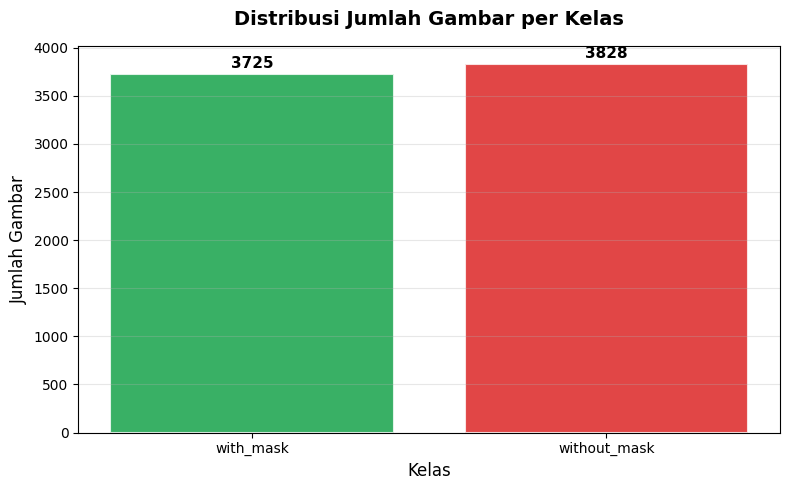

In [ ]:
# Bar chart distribusi kelas
counts = []
for cls in CLASSES:
    path = os.path.join(DATASET_DIR, cls)
    counts.append(len(os.listdir(path)))

colors = ['#16a34a', '#dc2626']
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(CLASSES, counts, color=colors, alpha=0.85, edgecolor='white', linewidth=1.5)
ax.set_title('Distribusi Jumlah Gambar per Kelas', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Kelas', fontsize=12)
ax.set_ylabel('Jumlah Gambar', fontsize=12)
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontweight='bold', fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

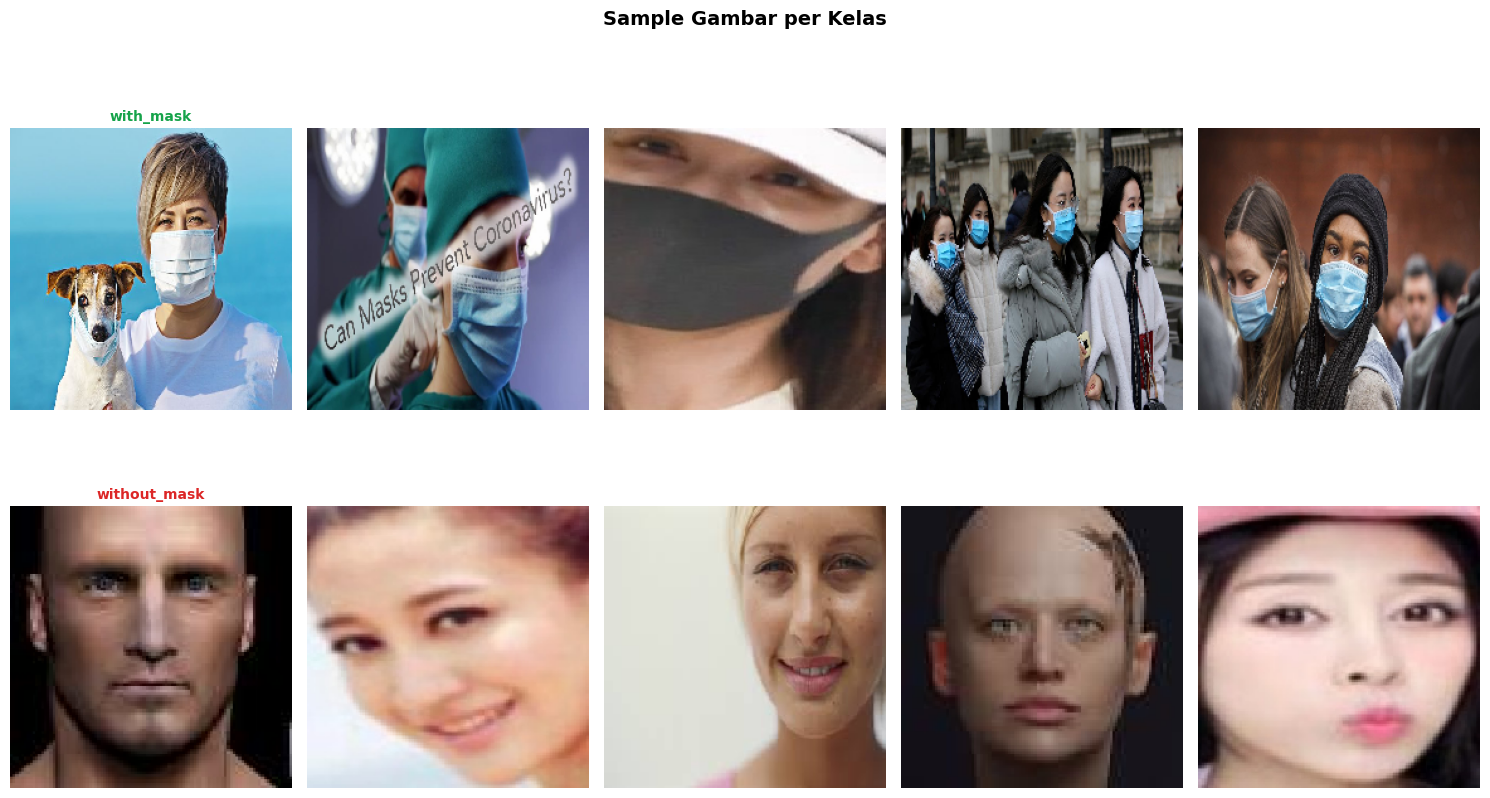

In [ ]:
# Tampilkan 5 sample gambar tiap kelas
fig, axes = plt.subplots(2, 5, figsize=(15, 9))
fig.suptitle('Sample Gambar per Kelas', fontsize=14, fontweight='bold')

label_colors = {'with_mask': '#16a34a', 'without_mask': '#dc2626'}

for row, cls in enumerate(CLASSES):
    folder = os.path.join(DATASET_DIR, cls)
    imgs   = [f for f in os.listdir(folder) if f.lower().endswith(('.jpg','.jpeg','.png'))][:5]
    for col, img_name in enumerate(imgs):
        img = load_img(os.path.join(folder, img_name), target_size=(224,224))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_title(cls, fontsize=10, color=label_colors[cls], fontweight='bold')

plt.tight_layout()
plt.show()

---
## Preprocessing & Split Data

In [ ]:
# Augmentasi untuk TRAINING
train_datagen = ImageDataGenerator(
    rescale=1.0/255.0,
    rotation_range=20,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    shear_range=0.1,
    fill_mode='nearest',
    validation_split=0.2    # 80% train, 20% validasi
)

# Untuk TEST: HANYA rescale, tanpa augmentasi
test_datagen = ImageDataGenerator(rescale=1.0/255.0)

# Training generator
train_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    subset='training',
    seed=SEED
)

# Validasi generator
val_gen = train_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    subset='validation',
    shuffle=False,
    seed=SEED
)

# Test generator (pakai val data sebagai test)
test_gen = test_datagen.flow_from_directory(
    DATASET_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    classes=CLASSES,
    shuffle=False
)

class_indices = train_gen.class_indices
idx_to_label  = {v: k for k, v in class_indices.items()}
NUM_CLASSES   = len(CLASSES)

print('Class indices:', class_indices)
print(f'Train samples : {train_gen.samples}')
print(f'Val samples   : {val_gen.samples}')
print(f'Jumlah kelas  : {NUM_CLASSES}')

Found 6043 images belonging to 2 classes.
Found 1510 images belonging to 2 classes.
Found 7553 images belonging to 2 classes.
Class indices: {'with_mask': 0, 'without_mask': 1}
Train samples : 6043
Val samples   : 1510
Jumlah kelas  : 2


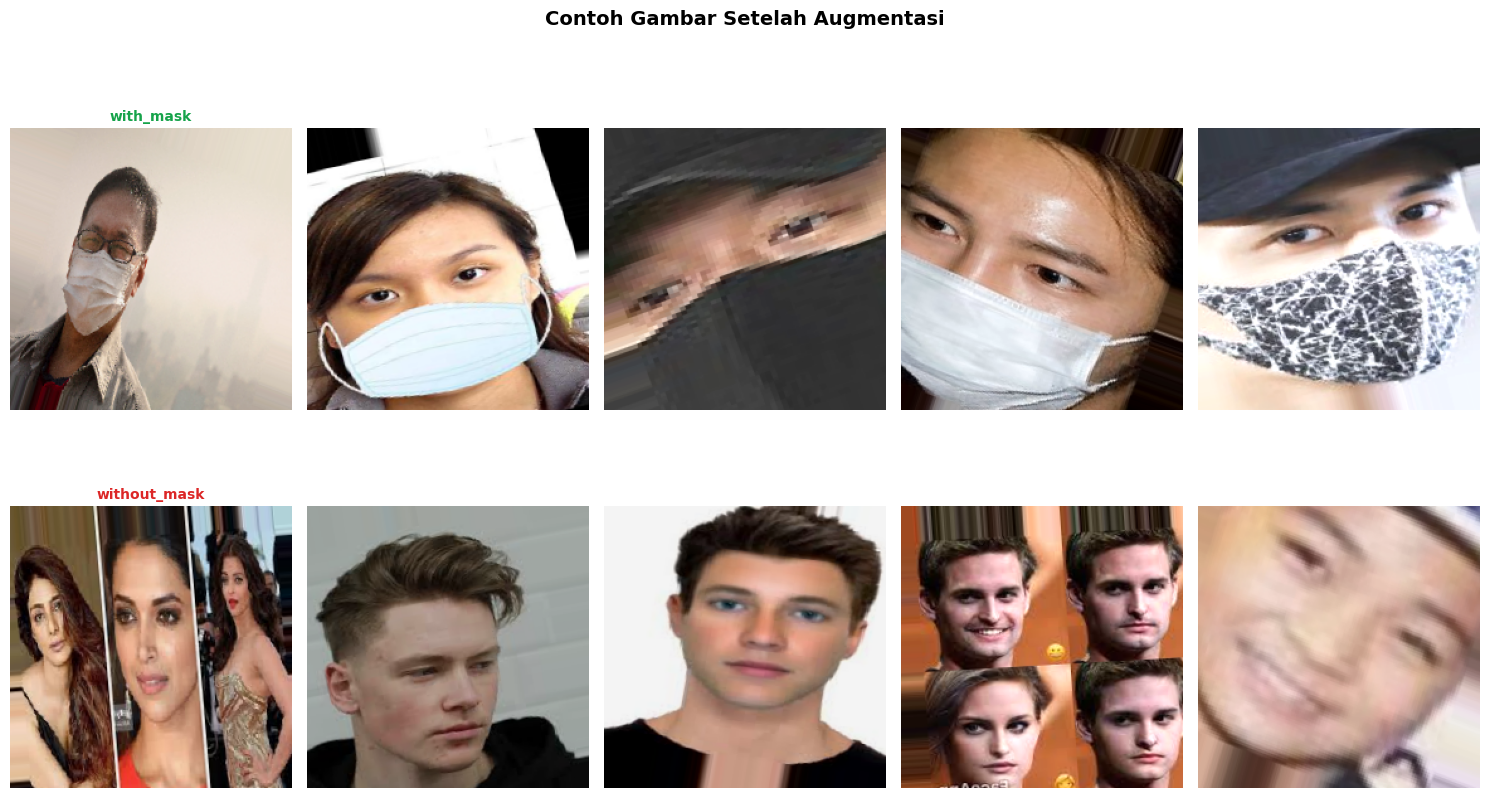

In [ ]:
# Visualisasi contoh augmentasi
batch_imgs, batch_labels = next(train_gen)

fig, axes = plt.subplots(2, 5, figsize=(15, 9))
fig.suptitle('Contoh Gambar Setelah Augmentasi', fontsize=14, fontweight='bold')

label_colors = ['#16a34a', '#dc2626']
shown = {0:0, 1:0}

for img, lbl in zip(batch_imgs, batch_labels):
    idx = int(round(lbl))
    if shown[idx] < 5:
        axes[idx][shown[idx]].imshow(img)
        axes[idx][shown[idx]].axis('off')
        if shown[idx] == 0:
            axes[idx][0].set_title(CLASSES[idx], color=label_colors[idx],
                                   fontweight='bold', fontsize=10)
        shown[idx] += 1
    if all(v >= 5 for v in shown.values()):
        break

plt.tight_layout()
plt.show()

---
## Build Model CNN from Scratch (2 Kelas)

In [ ]:
model = Sequential([
    # Block 1 — deteksi fitur dasar (tepi, warna)
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D(2,2),                  # 224x224 → 112x112

    # Block 2 — fitur menengah (tekstur)
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),                  # 112x112 → 56x56

    # Block 3 — fitur kompleks (bentuk masker)
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),                  # 56x56 → 28x28

    # Block 4 — fitur tingkat tinggi
    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2,2),                  # 28x28 → 14x14

    # Classifier
    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),                       # cegah overfitting
    Dense(1, activation='sigmoid')  # output: [prob_mask, prob_nomask]
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),  # LR lebih besar karena dari nol
    loss='binary_crossentropy',
    metrics=['accuracy']
)

total_params     = model.count_params()
trainable_params = sum(tf.size(w).numpy() for w in model.trainable_weights)
print(f'Total parameter     : {total_params:,}')
print(f'Trainable parameter : {trainable_params:,}')
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Total parameter     : 13,235,905
Trainable parameter : 13,234,945


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,905 (50.49 MB)

 Trainable params: 13,234,945 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

---
## Training — 1 Fase (CNN from Scratch)

In [ ]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ModelCheckpoint('best_model.h5', monitor='val_accuracy', save_best_only=True, verbose=1)
]

print('=== Training CNN from Scratch ===')
print(f'Epochs: 50 | Batch size: {BATCH_SIZE} | LR: 1e-3\n')

history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=50,          # lebih banyak karena belajar dari nol
    callbacks=callbacks
)

=== Training CNN from Scratch ===
Epochs: 50 | Batch size: 32 | LR: 1e-3

Epoch 1/50
 25/189 ━━━━━━━━━━━━━━━━━━━━ 18:50 7s/step - accuracy: 0.6765 - loss: 9.5929

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.7608 - loss: 3.7912
Epoch 1: val_accuracy improved from None to 0.57550, saving model to best_model.h5



Epoch 1: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 1691s 9s/step - accuracy: 0.7903 - loss: 1.6312 - val_accuracy: 0.5755 - val_loss: 3.5587 - learning_rate: 0.0010
Epoch 2/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.8384 - loss: 0.3784
Epoch 2: val_accuracy improved from 0.57550 to 0.72848, saving model to best_model.h5



Epoch 2: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 136s 719ms/step - accuracy: 0.8501 - loss: 0.3546 - val_accuracy: 0.7285 - val_loss: 2.5675 - learning_rate: 0.0010
Epoch 3/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 568ms/step - accuracy: 0.8496 - loss: 0.3461
Epoch 3: val_accuracy improved from 0.72848 to 0.80861, saving model to best_model.h5


...


Epoch 8: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 152s 804ms/step - accuracy: 0.9037 - loss: 0.2248 - val_accuracy: 0.9238 - val_loss: 0.1848 - learning_rate: 5.0000e-04
Epoch 9/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.9124 - loss: 0.1964
Epoch 9: val_accuracy did not improve from 0.92384
189/189 ━━━━━━━━━━━━━━━━━━━━ 134s 706ms/step - accuracy: 0.9128 - loss: 0.2027 - val_accuracy: 0.9020 - val_loss: 0.2951 - learning_rate: 5.0000e-04
Epoch 10/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9273 - loss: 0.1826
Epoch 10: val_accuracy did not improve from 0.92384
189/189 ━━━━━━━━━━━━━━━━━━━━ 133s 704ms/step - accuracy: 0.9237 - loss: 0.1886 - val_accuracy: 0.8384 - val_loss: 0.5479 - learning_rate: 5.0000e-04
Epoch 11/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 571ms/step - accuracy: 0.9298 - loss: 0.1790
Epoch 11: val_accuracy improved from 0.92384 to 0.94636, saving model to best_model.h5



Epoch 11: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 133s 703ms/step - accuracy: 0.9312 - loss: 0.1775 - val_accuracy: 0.9464 - val_loss: 0.1551 - learning_rate: 5.0000e-04
Epoch 12/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 576ms/step - accuracy: 0.9333 - loss: 0.1777
Epoch 12: val_accuracy did not improve from 0.94636
189/189 ━━━━━━━━━━━━━━━━━━━━ 135s 711ms/step - accuracy: 0.9368 - loss: 0.1718 - val_accuracy: 0.9179 - val_loss: 0.1984 - learning_rate: 5.0000e-04
Epoch 13/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9423 - loss: 0.1560
Epoch 13: val_accuracy did not improve from 0.94636
189/189 ━━━━━━━━━━━━━━━━━━━━ 133s 706ms/step - accuracy: 0.9426 - loss: 0.1584 - val_accuracy: 0.8828 - val_loss: 0.2868 - learning_rate: 5.0000e-04
Epoch 14/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9447 - loss: 0.1455
Epoch 14: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 14: val_accuracy did not improve from 0.94636
18


Epoch 20: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 134s 711ms/step - accuracy: 0.9739 - loss: 0.0762 - val_accuracy: 0.9583 - val_loss: 0.1109 - learning_rate: 1.2500e-04
Epoch 21/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.9752 - loss: 0.0711
Epoch 21: val_accuracy did not improve from 0.95828
189/189 ━━━━━━━━━━━━━━━━━━━━ 136s 718ms/step - accuracy: 0.9772 - loss: 0.0636 - val_accuracy: 0.9364 - val_loss: 0.2274 - learning_rate: 1.2500e-04
Epoch 22/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 579ms/step - accuracy: 0.9777 - loss: 0.0707
Epoch 22: val_accuracy did not improve from 0.95828
189/189 ━━━━━━━━━━━━━━━━━━━━ 134s 708ms/step - accuracy: 0.9788 - loss: 0.0673 - val_accuracy: 0.9470 - val_loss: 0.1420 - learning_rate: 1.2500e-04
Epoch 23/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9728 - loss: 0.0738
Epoch 23: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 23: val_accuracy improved from 0.95828 to 0.96623


Epoch 23: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 146s 730ms/step - accuracy: 0.9748 - loss: 0.0674 - val_accuracy: 0.9662 - val_loss: 0.1232 - learning_rate: 1.2500e-04
Epoch 24/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9796 - loss: 0.0556
Epoch 24: val_accuracy did not improve from 0.96623
189/189 ━━━━━━━━━━━━━━━━━━━━ 136s 718ms/step - accuracy: 0.9811 - loss: 0.0519 - val_accuracy: 0.9636 - val_loss: 0.1001 - learning_rate: 6.2500e-05
Epoch 25/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 590ms/step - accuracy: 0.9809 - loss: 0.0490
Epoch 25: val_accuracy did not improve from 0.96623
189/189 ━━━━━━━━━━━━━━━━━━━━ 137s 728ms/step - accuracy: 0.9821 - loss: 0.0491 - val_accuracy: 0.9563 - val_loss: 0.1242 - learning_rate: 6.2500e-05
Epoch 26/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 587ms/step - accuracy: 0.9821 - loss: 0.0502
Epoch 26: val_accuracy did not improve from 0.96623
189/189 ━━━━━━━━━━━━━━━━━━━━ 136s 720ms/step - accuracy: 0.9831 - loss: 0.0496 -


Epoch 29: finished saving model to best_model.h5
189/189 ━━━━━━━━━━━━━━━━━━━━ 135s 717ms/step - accuracy: 0.9854 - loss: 0.0428 - val_accuracy: 0.9689 - val_loss: 0.1002 - learning_rate: 6.2500e-05
Epoch 30/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 582ms/step - accuracy: 0.9832 - loss: 0.0483
Epoch 30: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 30: val_accuracy did not improve from 0.96887
189/189 ━━━━━━━━━━━━━━━━━━━━ 136s 718ms/step - accuracy: 0.9820 - loss: 0.0520 - val_accuracy: 0.9570 - val_loss: 0.1470 - learning_rate: 6.2500e-05
Epoch 31/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 583ms/step - accuracy: 0.9859 - loss: 0.0403
Epoch 31: val_accuracy did not improve from 0.96887
189/189 ━━━━━━━━━━━━━━━━━━━━ 134s 712ms/step - accuracy: 0.9861 - loss: 0.0399 - val_accuracy: 0.9636 - val_loss: 0.1328 - learning_rate: 3.1250e-05
Epoch 32/50
189/189 ━━━━━━━━━━━━━━━━━━━━ 0s 585ms/step - accuracy: 0.9901 - loss: 0.0320
Epoch 32: val_accuracy did not improve from 0.96887
18

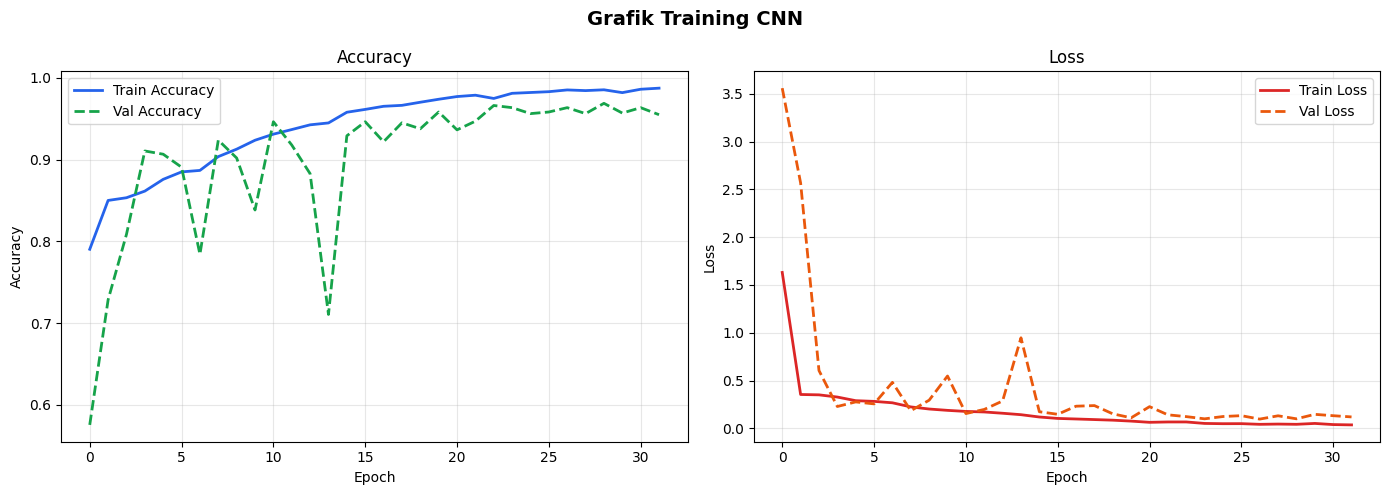


=== Ringkasan Training ===

Berhenti di epoch : 32
Best epoch        : 29 (val_acc: 96.89%)
Best val_loss     : 0.0972


In [ ]:
# Plot grafik training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Grafik Training CNN', fontsize=14, fontweight='bold')

ax1.plot(history.history['accuracy'],     label='Train Accuracy', color='#2563eb', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Val Accuracy',   color='#16a34a', linestyle='--', linewidth=2)
ax1.set_title('Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history.history['loss'],     label='Train Loss', color='#dc2626', linewidth=2)
ax2.plot(history.history['val_loss'], label='Val Loss',   color='#ea580c', linestyle='--', linewidth=2)
ax2.set_title('Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ringkasan training
actual_epoch = len(history.history['accuracy'])
best_epoch   = np.argmax(history.history['val_accuracy']) + 1

print()
print('=== Ringkasan Training ===')
print()
print(f'Berhenti di epoch : {actual_epoch}')
print(f'Best epoch        : {best_epoch} (val_acc: {max(history.history["val_accuracy"])*100:.2f}%)')
print(f'Best val_loss     : {min(history.history["val_loss"]):.4f}')

---
## Evaluasi Model

In [ ]:
best_model = load_model('best_model.h5')

print('=== Evaluasi pada Validation Set ===')
val_loss_score, val_acc_score = best_model.evaluate(val_gen, verbose=1)
print(f'\nValidation Accuracy : {val_acc_score*100:.2f}%')
print(f'Validation Loss     : {val_loss_score:.4f}')

=== Evaluasi pada Validation Set ===
48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 537ms/step - accuracy: 0.9722 - loss: 0.0885

Validation Accuracy : 97.22%
Validation Loss     : 0.0885


In [ ]:
# Prediksi seluruh validation set
val_gen.reset()
y_pred_probs = best_model.predict(val_gen, verbose=1)
y_pred = (y_pred_probs.flatten() > 0.5).astype(int)
y_true = val_gen.classes

print('\n=== Classification Report ===')
print(classification_report(y_true, y_pred, target_names=CLASSES, digits=4))

48/48 ━━━━━━━━━━━━━━━━━━━━ 27s 537ms/step

=== Classification Report ===
              precision    recall  f1-score   support

   with_mask     0.9556    0.9826    0.9689       745
without_mask     0.9825    0.9556    0.9689       765

    accuracy                         0.9689      1510
   macro avg     0.9691    0.9691    0.9689      1510
weighted avg     0.9692    0.9689    0.9689      1510



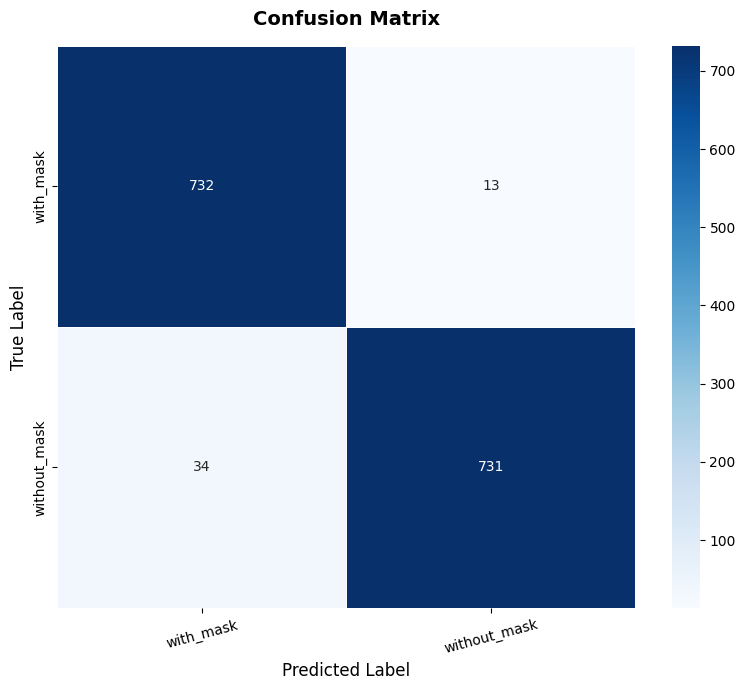

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=CLASSES,
    yticklabels=CLASSES,
    linewidths=0.5,
    ax=ax
)
ax.set_title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label', fontsize=12)
ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

In [ ]:
# Ringkasan metrik per kelas
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(y_true, y_pred, average=None)
macro_p, macro_r, macro_f1, _ = precision_recall_fscore_support(y_true, y_pred, average='macro')

print('=== Ringkasan Metrik per Kelas ===')
print(f'{"Kelas":<20} {"Precision":>10} {"Recall":>10} {"F1-Score":>10} {"Support":>10}')
print('-' * 60)
for i, cls in enumerate(CLASSES):
    print(f'{cls:<20} {precision[i]*100:>9.2f}% {recall[i]*100:>9.2f}% {f1[i]*100:>9.2f}% {support[i]:>10}')
print('-' * 60)
print(f'{"Macro Avg":<20} {macro_p*100:>9.2f}% {macro_r*100:>9.2f}% {macro_f1*100:>9.2f}%')
print(f'\nOverall Accuracy: {val_acc_score*100:.2f}%')

=== Ringkasan Metrik per Kelas ===
Kelas                 Precision     Recall   F1-Score    Support
------------------------------------------------------------
with_mask                95.56%     98.26%     96.89%        745
without_mask             98.25%     95.56%     96.89%        765
------------------------------------------------------------
Macro Avg                96.91%     96.91%     96.89%

Overall Accuracy: 97.22%


---
## Inference — Prediksi Gambar Baru

In [ ]:
def predict_image(img_path, model, idx_to_label, img_size=(224,224)):
    # Preprocessing HARUS sama persis dengan training
    img  = load_img(img_path, target_size=img_size)
    arr  = img_to_array(img) / 255.0          # normalisasi 0-1
    arr  = np.expand_dims(arr, axis=0)        # tambah dimensi batch

    prob_mask   = float(model.predict(arr, verbose=0)[0][0])
    pred_idx    = int(prob_mask > 0.5)   # 0 = with_mask, 1 = without_mask
    label       = idx_to_label[pred_idx]
    conf        = prob_mask * 100 if pred_idx == 1 else (1 - prob_mask) * 100
    all_prob    = {
        idx_to_label[0]: (1 - prob_mask) * 100,
        idx_to_label[1]: prob_mask * 100
    }
    return label, conf, all_prob


def show_prediction(img_path, model, idx_to_label):
    label, conf, all_prob = predict_image(img_path, model, idx_to_label)
    color_map = {'with_mask':'#16a34a', 'without_mask':'#dc2626'}
    color = color_map.get(label, '#6b7280')

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

    img = load_img(img_path, target_size=(224,224))
    ax1.imshow(img)
    ax1.set_title(f'{label}\nKeyakinan: {conf:.1f}%', color=color, fontsize=12, fontweight='bold')
    ax1.axis('off')

    labels_list = list(all_prob.keys())
    probs_list  = list(all_prob.values())
    bar_colors  = [color_map.get(l, '#6b7280') for l in labels_list]
    bars = ax2.barh(labels_list, probs_list, color=bar_colors, alpha=0.8, edgecolor='white')
    ax2.set_xlim(0, 105)
    ax2.set_xlabel('Probabilitas (%)')
    ax2.set_title('Distribusi Probabilitas')
    for bar, v in zip(bars, probs_list):
        ax2.text(v + 1, bar.get_y() + bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=11)
    ax2.grid(axis='x', alpha=0.3)

    plt.tight_layout()
    plt.show()

print('Fungsi inference siap!')

Fungsi inference siap!



--- Ground Truth: with_mask ---


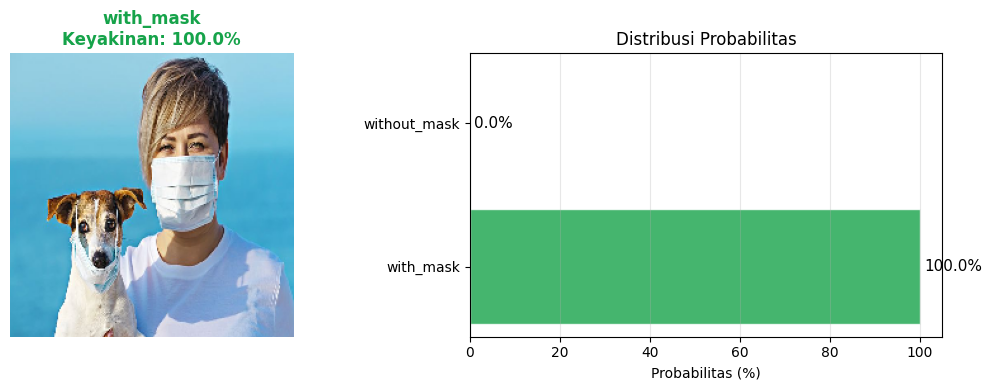


--- Ground Truth: without_mask ---


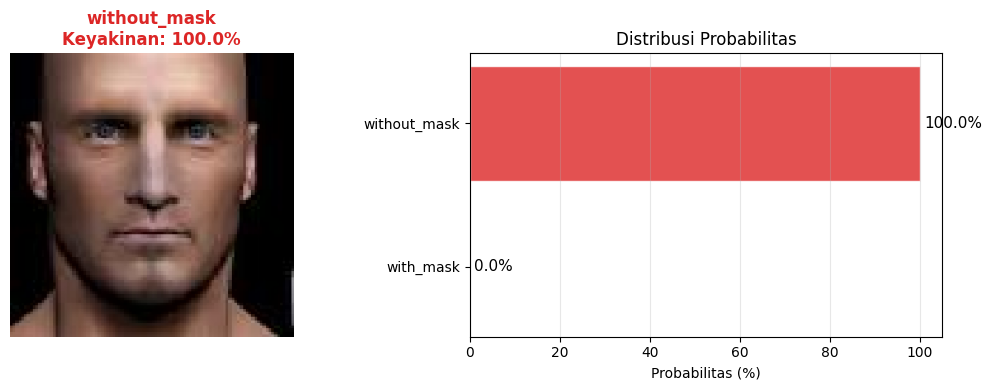

In [ ]:
# Test dengan 1 gambar dari tiap kelas
idx_to_label_loaded = idx_to_label

for cls in CLASSES:
    folder   = os.path.join(DATASET_DIR, cls)
    img_file = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_file)
    print(f'\n--- Ground Truth: {cls} ---')
    show_prediction(img_path, best_model, idx_to_label_loaded)

Upload gambar untuk dicoba:


Saving 1-removebg-preview.png to 1-removebg-preview (1).png

=== Hasil: 1-removebg-preview (1).png ===


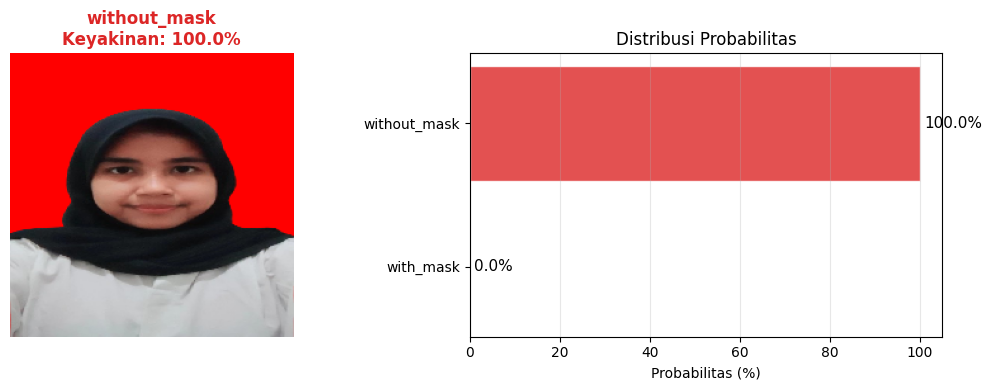

In [ ]:
# Upload & coba gambar sendiri
from google.colab import files
print('Upload gambar untuk dicoba:')
uploaded = files.upload()

for filename in uploaded.keys():
    print(f'\n=== Hasil: {filename} ===')
    show_prediction(filename, best_model, idx_to_label_loaded)

---
##  Simpan Model & Artefak

In [ ]:
# Simpan model .h5 (bukan joblib — CNN pakai format Keras)
best_model.save('mask_detector_final.h5')
print('✅ mask_detector_final.h5  — bobot CNN (Keras format)')

# Simpan label mapping pakai joblib (ini yang cocok pakai joblib)
joblib.dump(class_indices, 'class_indices.pkl')
joblib.dump(idx_to_label,  'idx_to_label.pkl')
print('✅ class_indices.pkl       — label mapping (joblib)')
print('✅ idx_to_label.pkl        — decode prediksi (joblib)')

# Simpan config ke JSON
config = {
    'model'        : 'CNN from Scratch',
    'img_size'     : list(IMG_SIZE),
    'num_classes'  : NUM_CLASSES,
    'classes'      : CLASSES,
    'class_indices': class_indices,
    'val_accuracy' : round(float(val_acc_score), 4),
    'val_loss'     : round(float(val_loss_score), 4)
}
with open('model_config.json', 'w') as f:
    json.dump(config, f, indent=2)
print('✅ model_config.json       — metadata model')

# Salin juga ke Google Drive
SAVE_TO_DRIVE = '/content/drive/MyDrive/model_masker'
os.makedirs(SAVE_TO_DRIVE, exist_ok=True)
import shutil
for f in ['mask_detector_final.h5','class_indices.pkl','idx_to_label.pkl','model_config.json']:
    shutil.copy(f, os.path.join(SAVE_TO_DRIVE, f))
print(f'\n✅ Semua file disalin ke Drive: {SAVE_TO_DRIVE}')

✅ mask_detector_final.h5  — bobot CNN (Keras format)
✅ class_indices.pkl       — label mapping (joblib)
✅ idx_to_label.pkl        — decode prediksi (joblib)
✅ model_config.json       — metadata model

✅ Semua file disalin ke Drive: /content/drive/MyDrive/model_masker
